# ISH and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare UFS-CHEM results against ISH surface observations for temperature, wind speed, and dewpoint.

ISH is a particularly useful for model evaluations because it is a global dataset. As you will see in the YAML file, we can create plots globally, for individual countries, and states. NOTE: MELODIES-MONET examples that use ISH will take longer to finish running due to the larger amount of data.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ish_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-03-00:00:00',
  'output_dir': './output/ish_ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': 'example:ufschem:2017-07',
   'mod_type': 'ufschem',
   'is_global': True,
   'mod_kwargs': {'surf_only': True},
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh'},
    'rel_hum': {'specific_hum': 'spfh'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
   'mapping': {'ish': {'temperature_k': 't',
     'windspeed': 'ws',
     'dewpoint': 'dpt'}},
   'variables': {'winddir': 'None'},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'linestyle': '-'}}},
 'obs': {'ish': {'filename': 'example:ish:2017-07',
   'obs_type': 'pt_sfc',
   'variables': {'t': {'unit_scale': 273.15,
     'unit_scale_method': '+',
     'nan_value': -1.0,
     'ylabel_plot': 'Temperature (K)',
     'xlabel_plot': 

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ish_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-03 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/ish_ufschem',
    output_dir_save='./output/ish_ufschem',
    output_dir_read='./output/ish_ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

ufschem
example:ufschem:2017-07
**** Reading UFS-CHEM model output...
Performing extra model calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...
Calculating modeled windpseed...
Calculating modeled wind direction...
No extra calculations performed.


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'ufschem_v1': model(
     model='ufschem',
     is_global=True,
     radius_of_influence=100000,
     mod_kwargs={'surf_only': True, 'var_list': ['spfh', 'ugrd', 'vgrd', 'lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufschem:2017-07',
     label='ufschem_v1',
     obj=...,
     extra_calc={'dewpoint': {'specific_hum': 'spfh'}, 'rel_hum': {'specific_hum': 'spfh'}, 'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
     mapping={'ish': {'temperature_k': 't', 'windspeed': 'ws', 'dewpoint': 'dpt'}},
     variable_dict={'winddir': 'None', 'spfh': 'None', 'ugrd': 'None', 'vgrd': 'None'},
     label='ufschem_v1',
     ...
 )}

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 362MB
Dimensions:        (time: 72, z: 1, y: 192, x: 384)
Coordinates:
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
Dimensions without coordinates: z, y, x
Data variables: (12/13)
    spfh           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dp_pa          (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    pres_pa_mid    (time, z, y, x) float32 21MB 37.92 37.92 ... 37.92 37.92
    dewpoint       (time, z, y, x) float64 42MB 271.7 271.7 ... 217.3 217.2
    rel_hum        (time, z, y, x) float64 42MB 94.35 94.35 ... 66.12 66.08
    windspeed      (time, z, y, x) float64 42MB 6.511 6.511 6.511 ... 6.09 6.085
    winddir        (time, z, y, x) float64 42MB 246.6 247.4 ... 350.2 349.4
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Wed Jun 25 09:54:47 2025: ncrcat 20170701_dynf001.nc 201707...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

In [10]:
an.obs

{'ish': observation(
     obs='ish',
     label='ish',
     file='example:ish:2017-07',
     obj=...,
     extra_calc=None,
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'t': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 12, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dpt': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Dewpoint (K)', 'xlabel_plot': 'Dewpoint (K)', 'vmin_pl

In [11]:
an.obs['ish']

observation(
    obs='ish',
    label='ish',
    file='example:ish:2017-07',
    obj=...,
    extra_calc=None,
    type='pt_src',
    sat_type=None,
    data_proc=None,
    variable_dict={'t': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 12, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dpt': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Dewpoint (K)', 'xlabel_plot': 'Dewpoint (K)', 'vmin_plot': 273.15, 'vma

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:               time  varlength   wdir   ws  ceiling      vsb       t     dpt  \
0      2017-07-01      108.0    NaN  NaN      NaN      NaN     NaN     NaN   
1      2017-07-01        NaN    NaN  NaN      NaN      NaN     NaN     NaN   
2      2017-07-01      108.0  320.0  4.0      NaN      NaN  271.15  271.15   
3      2017-07-01      244.0   80.0  2.0  22000.0  50000.0  275.15     NaN   
4      2017-07-01       89.0  330.0  2.0      NaN      NaN  274.15  270.15   
...           ...        ...    ...  ...      ...      ...     ...     ...   
603724 2017-07-03        NaN    NaN  NaN      NaN      NaN     NaN     NaN   
603725 2017-07-03        NaN    NaN  NaN      NaN      NaN     NaN     NaN   
603726 2017-07-03        NaN    NaN  NaN      NaN      NaN     NaN     NaN   
603727 2017-07-03        NaN    NaN  NaN      NaN      NaN     NaN     NaN   
603728 2017-07-03        NaN    NaN  NaN      NaN      NaN     NaN     NaN   

             p       siteid  ..

CPU times: user 37.6 s, sys: 14.8 s, total: 52.5 s
Wall time: 58.7 s


In [13]:
an.paired

{'ish_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='ish',
     model='ufschem_v1',
     model_vars=['temperature_k', 'windspeed', 'dewpoint'],
     obs_vars=['t', 'ws', 'dpt'],
     filename='ish_ufschem_v1.nc',
 )}

In [14]:
an.paired['ish_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='ish',
    model='ufschem_v1',
    model_vars=['temperature_k', 'windspeed', 'dewpoint'],
    obs_vars=['t', 'ws', 'dpt'],
    filename='ish_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated at the Country-, EPA region-, and MSA-scale 
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting wind barbs failed!
U-comp and V-comp need to be specified in the yaml file. Plotting

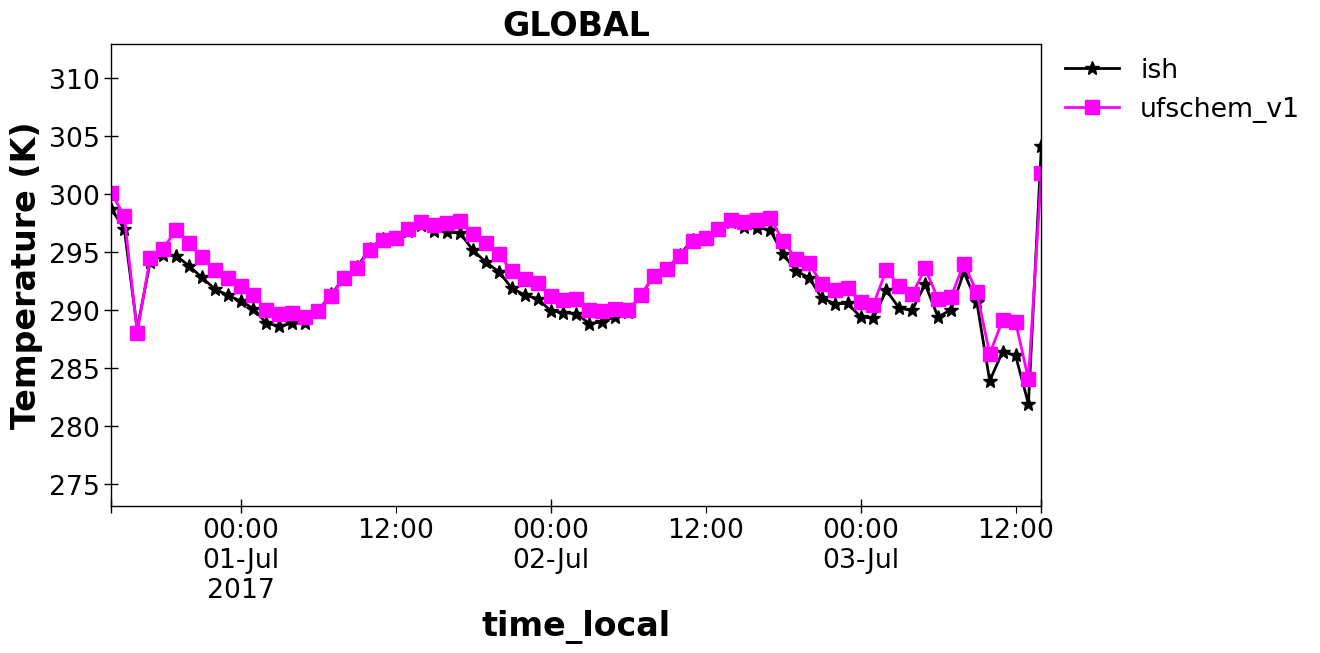

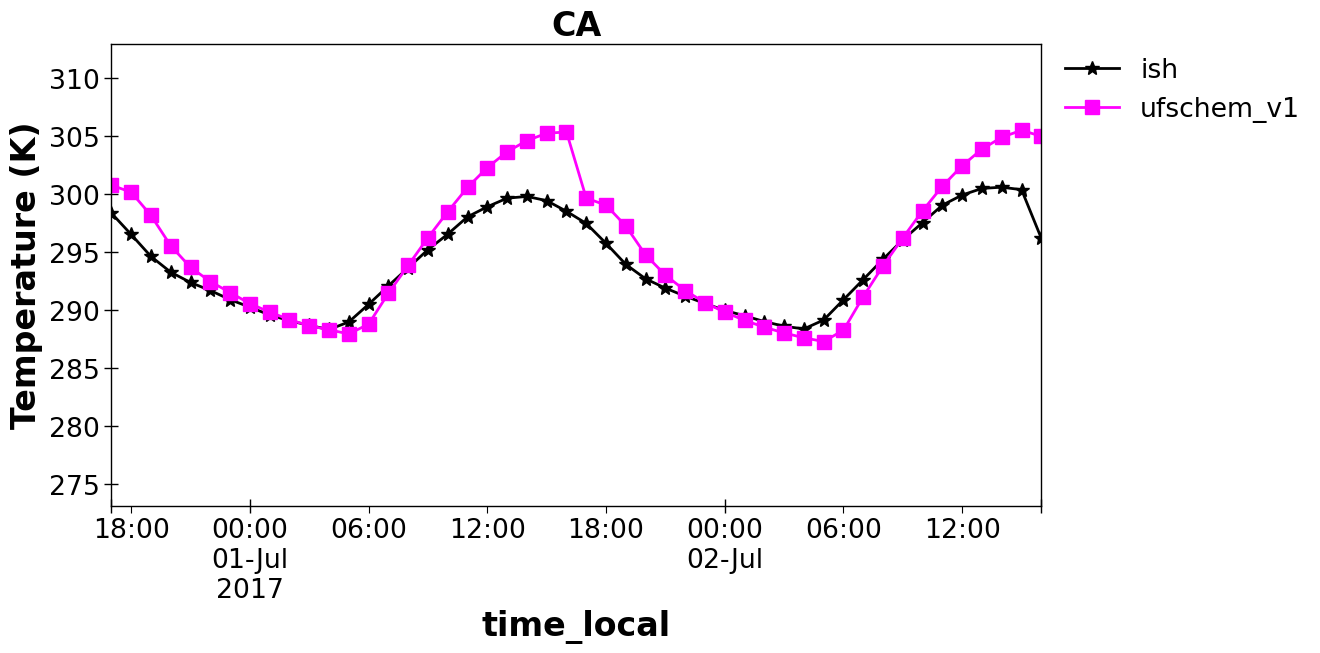

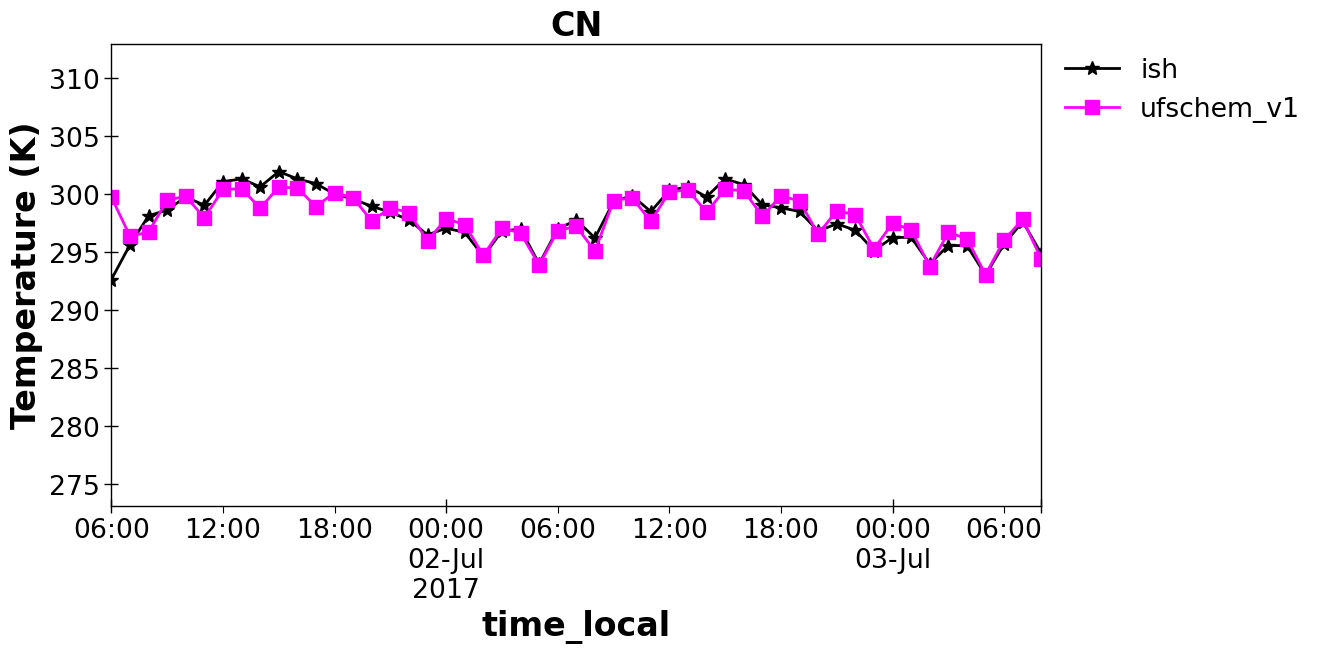

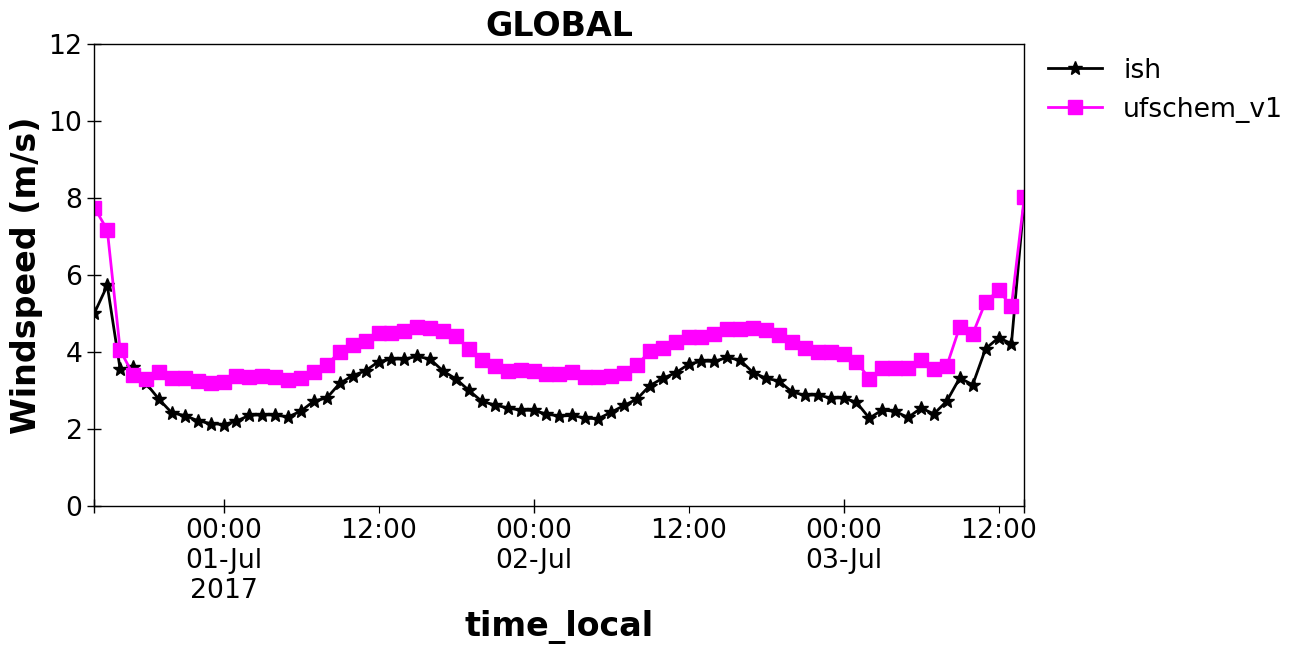

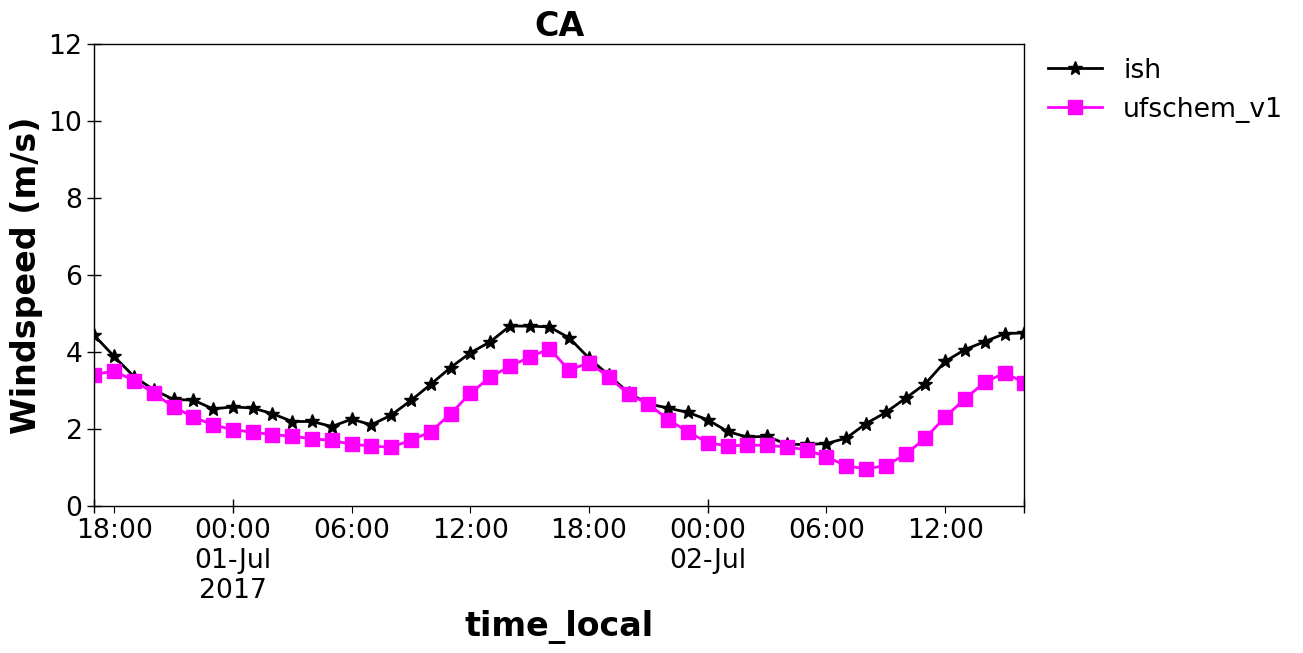

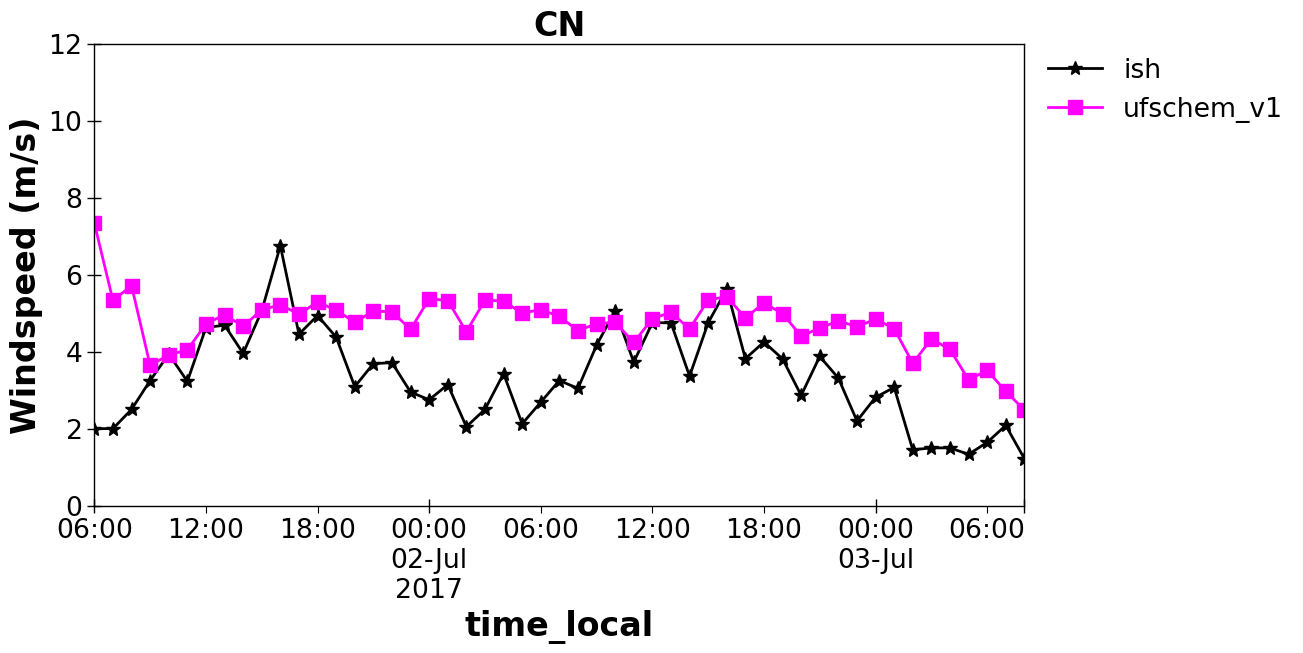

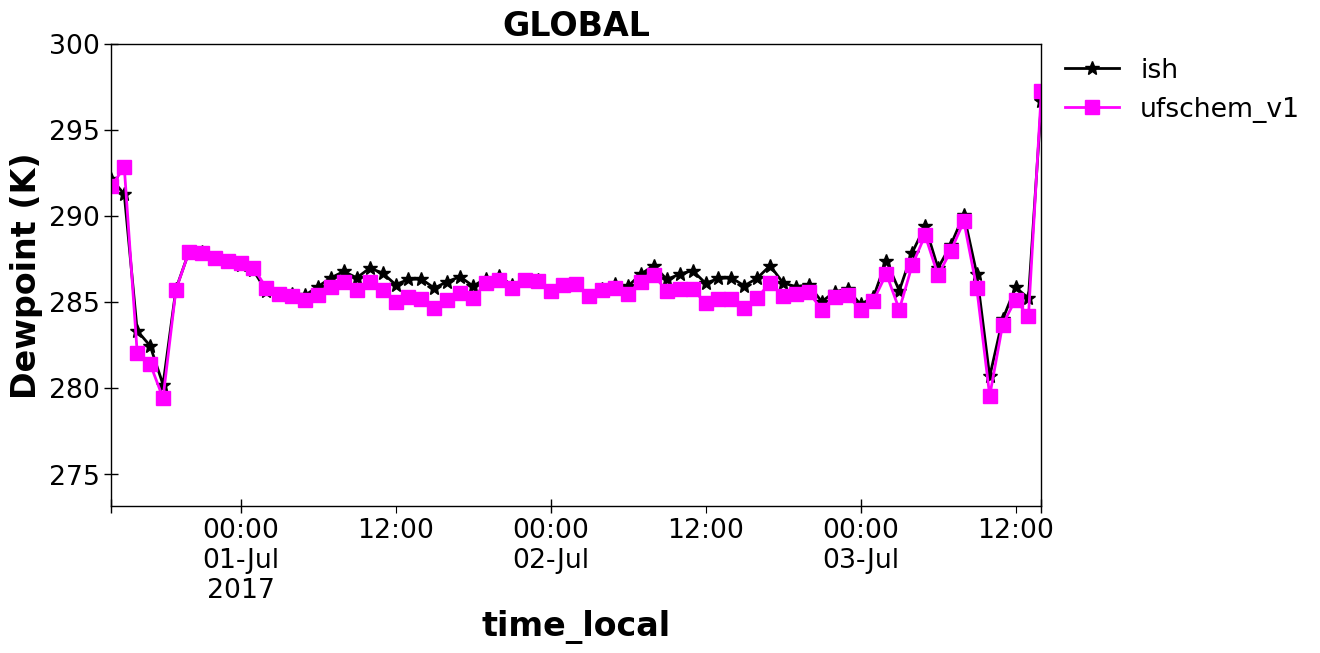

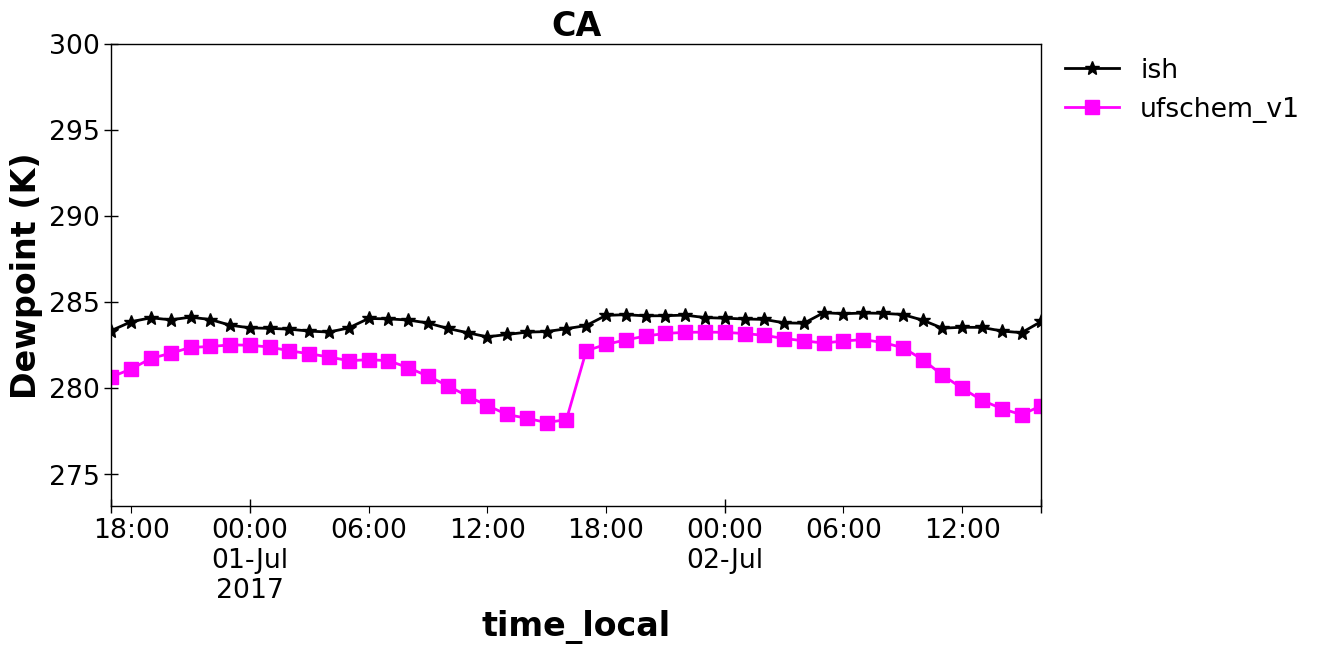

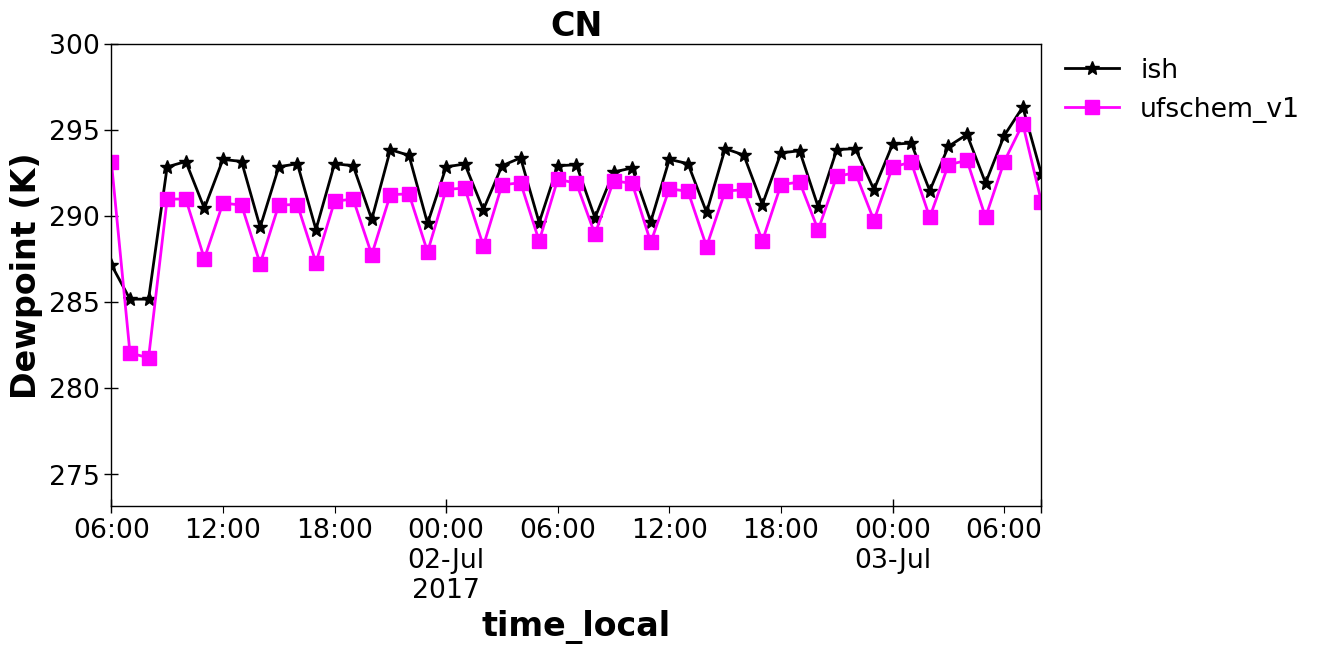

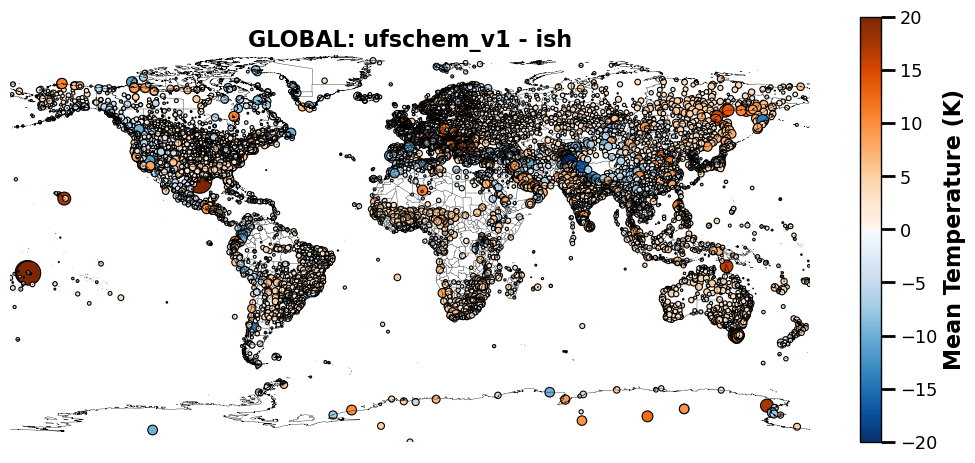

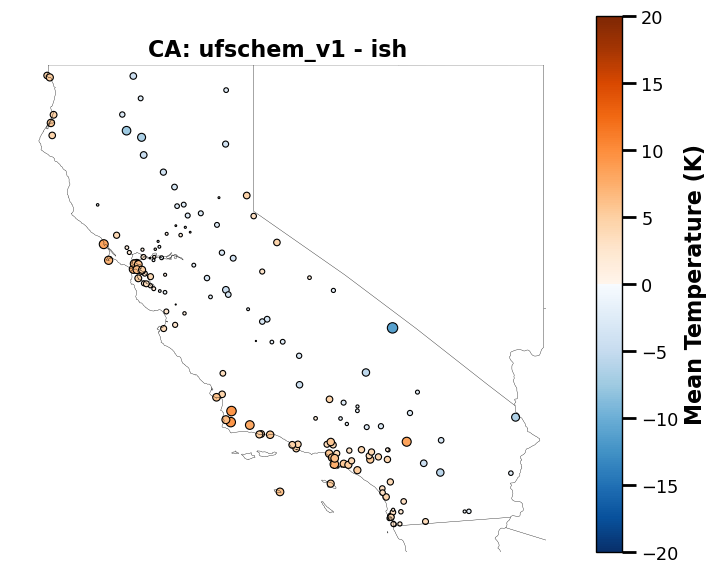

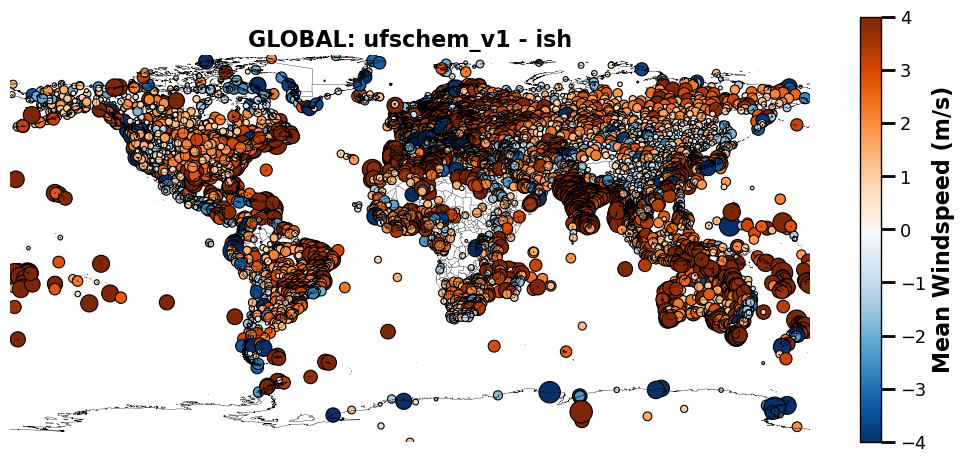

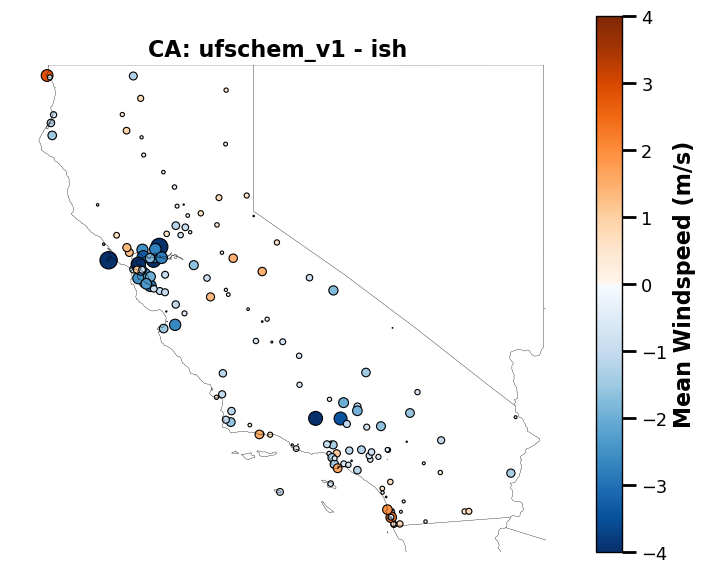

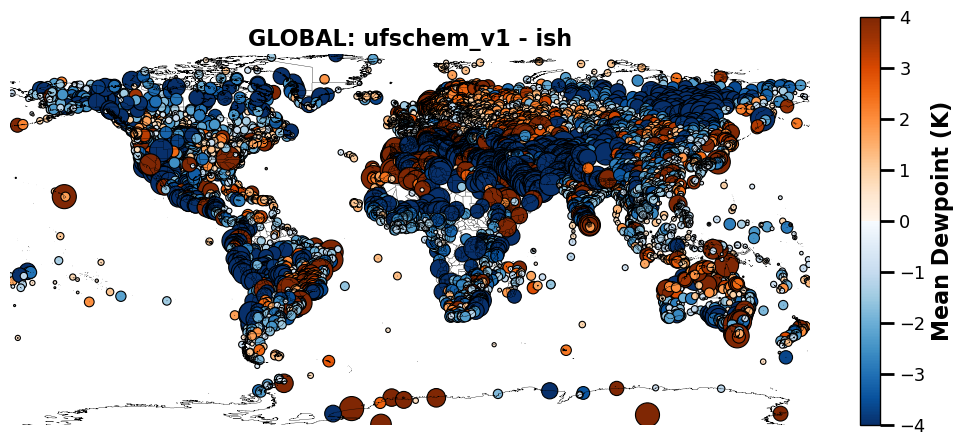

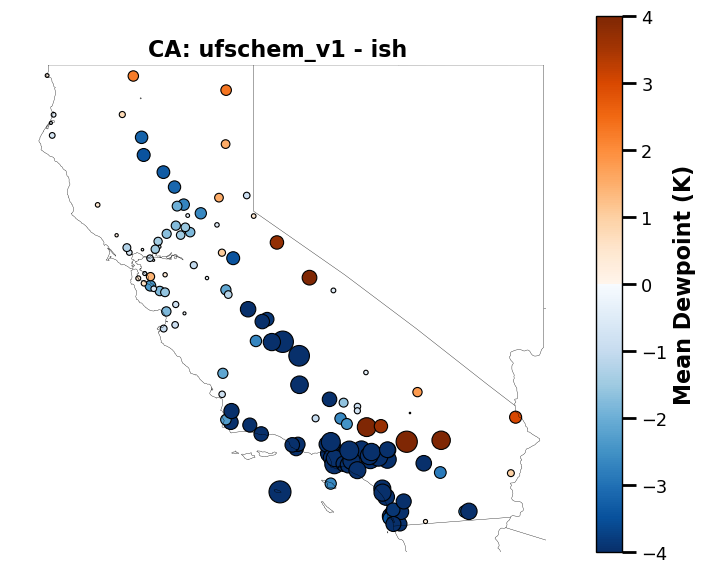

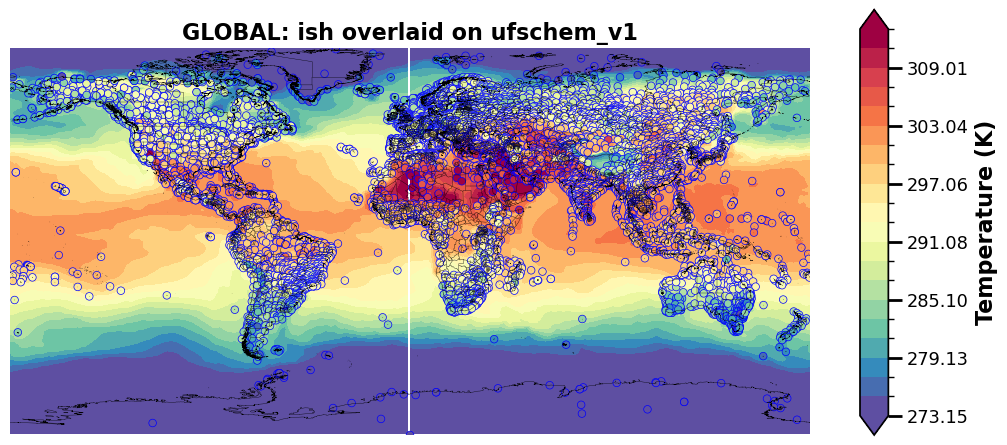

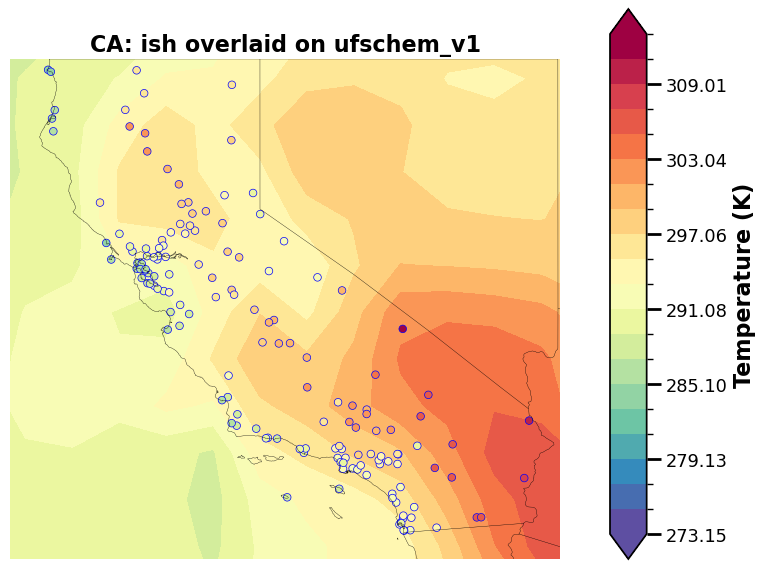

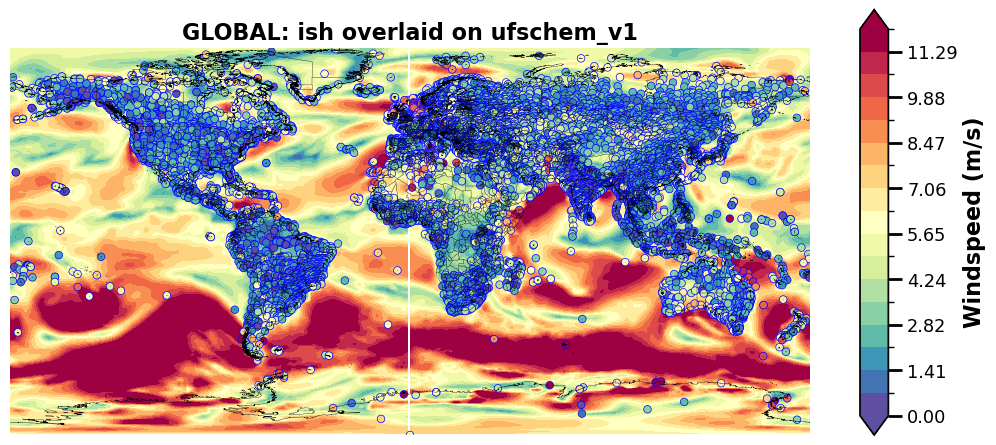

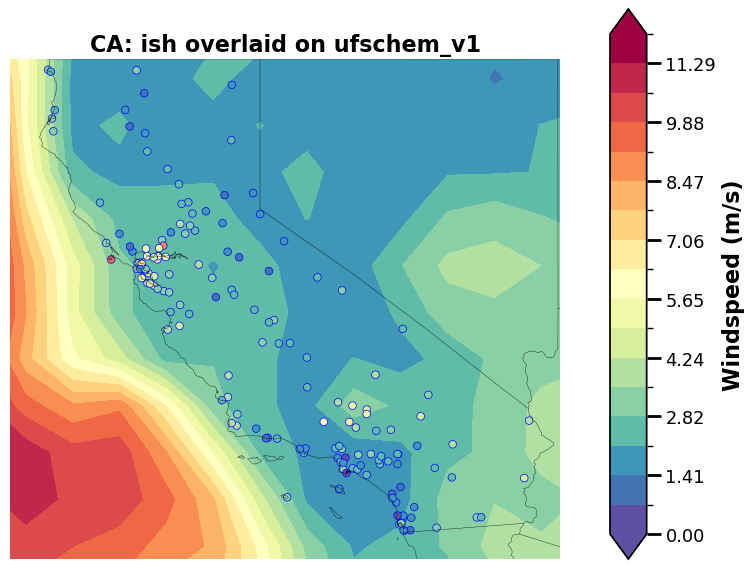

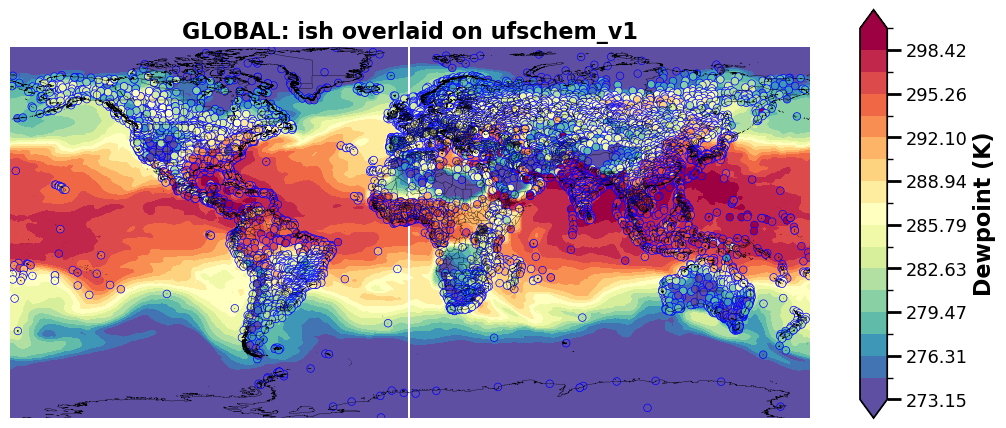

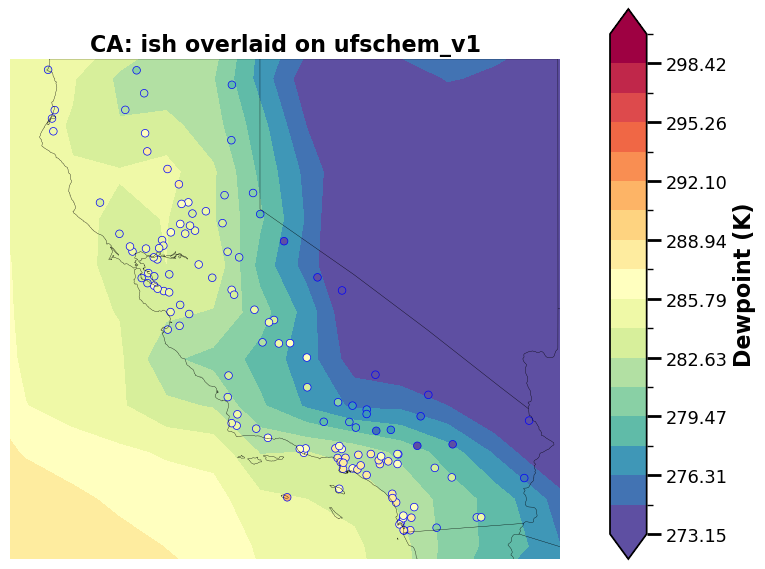

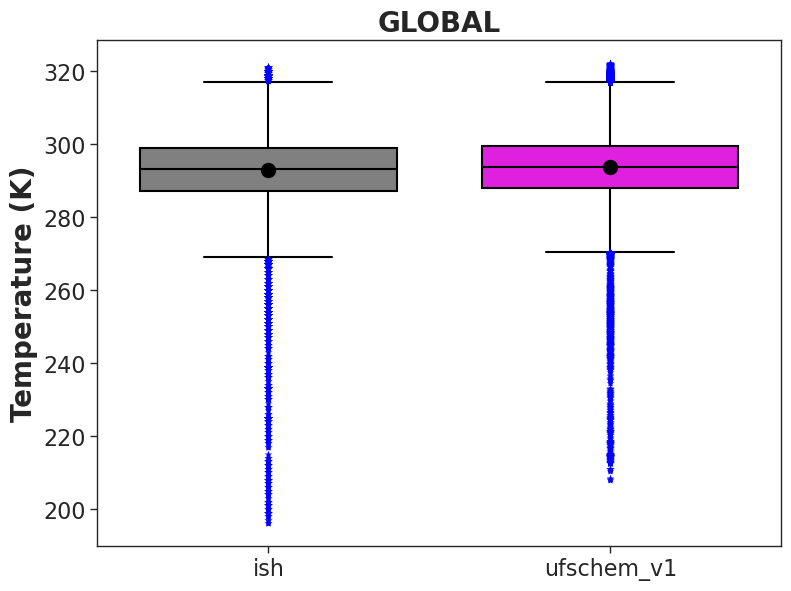

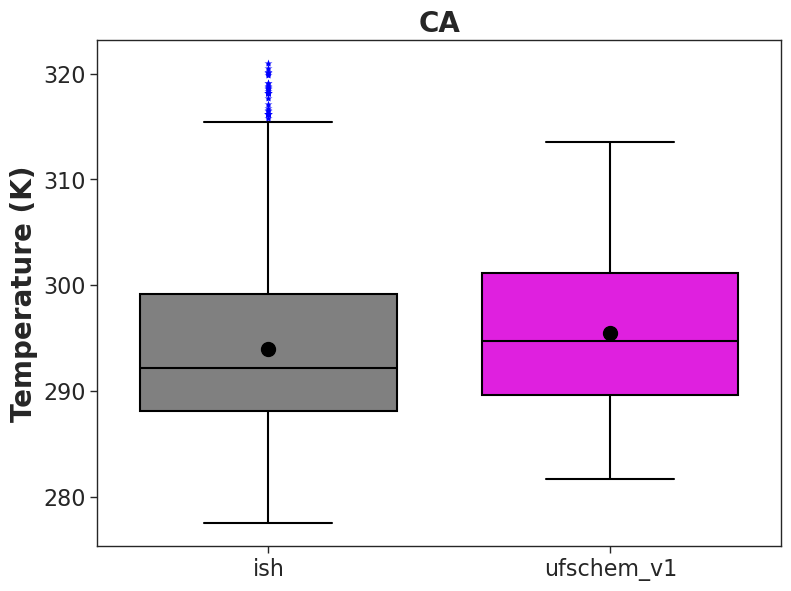

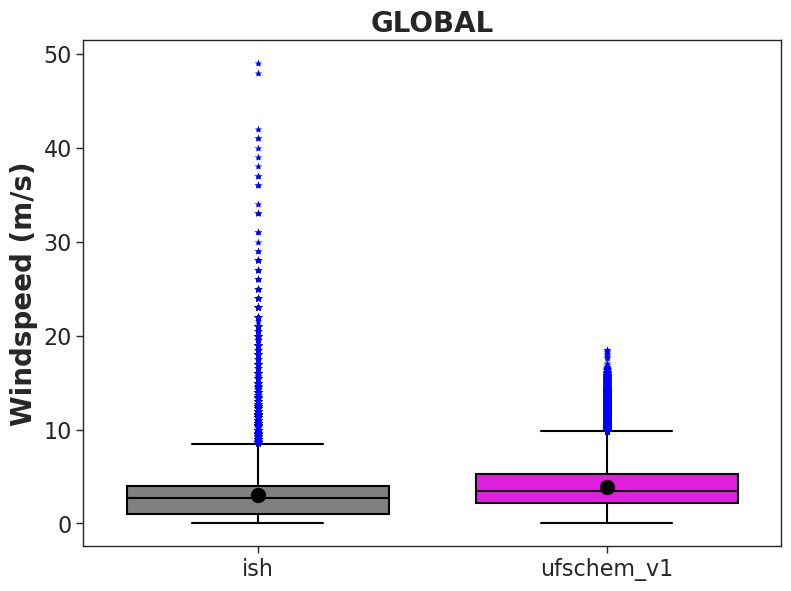

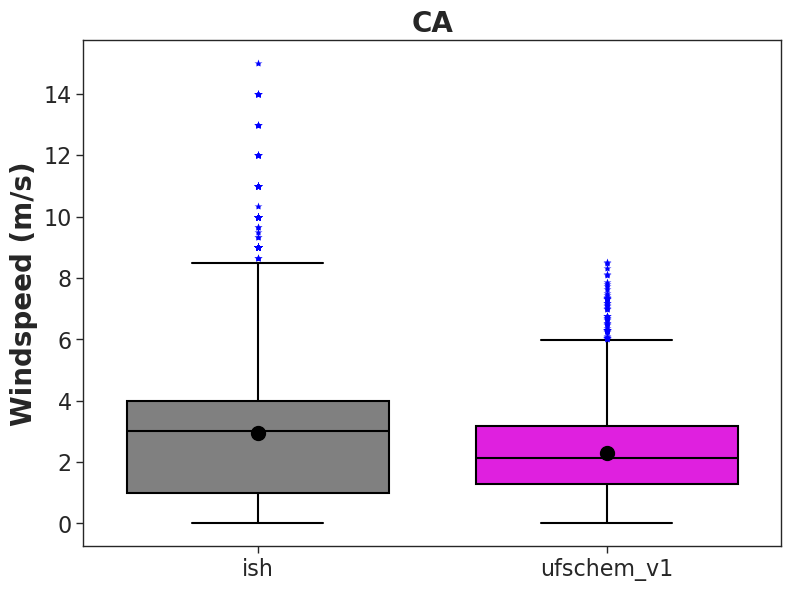

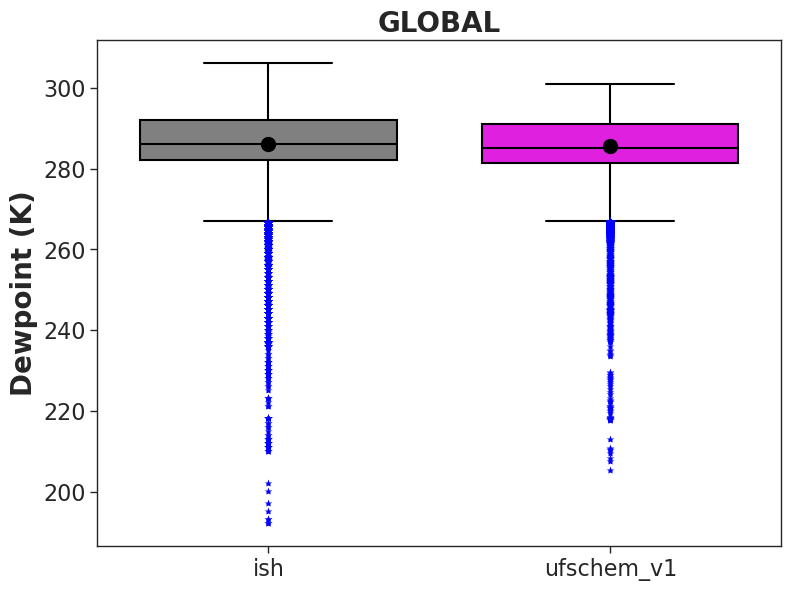

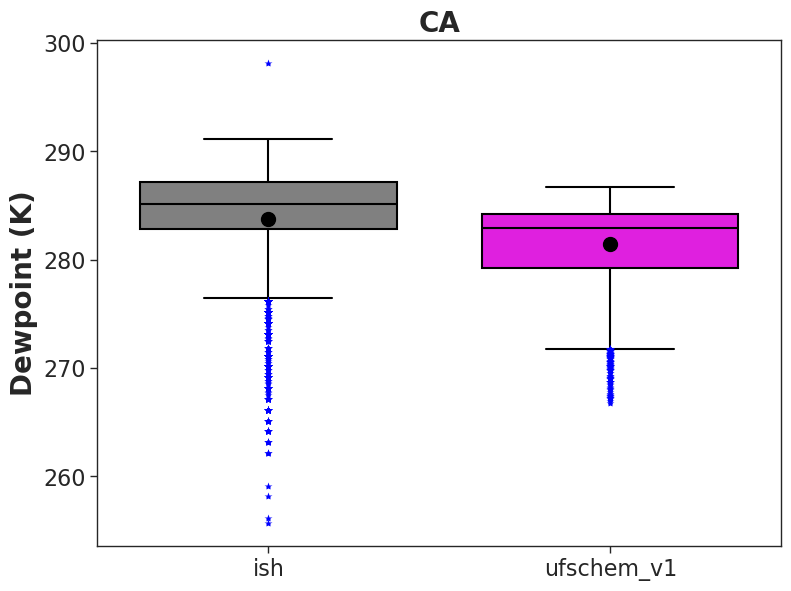

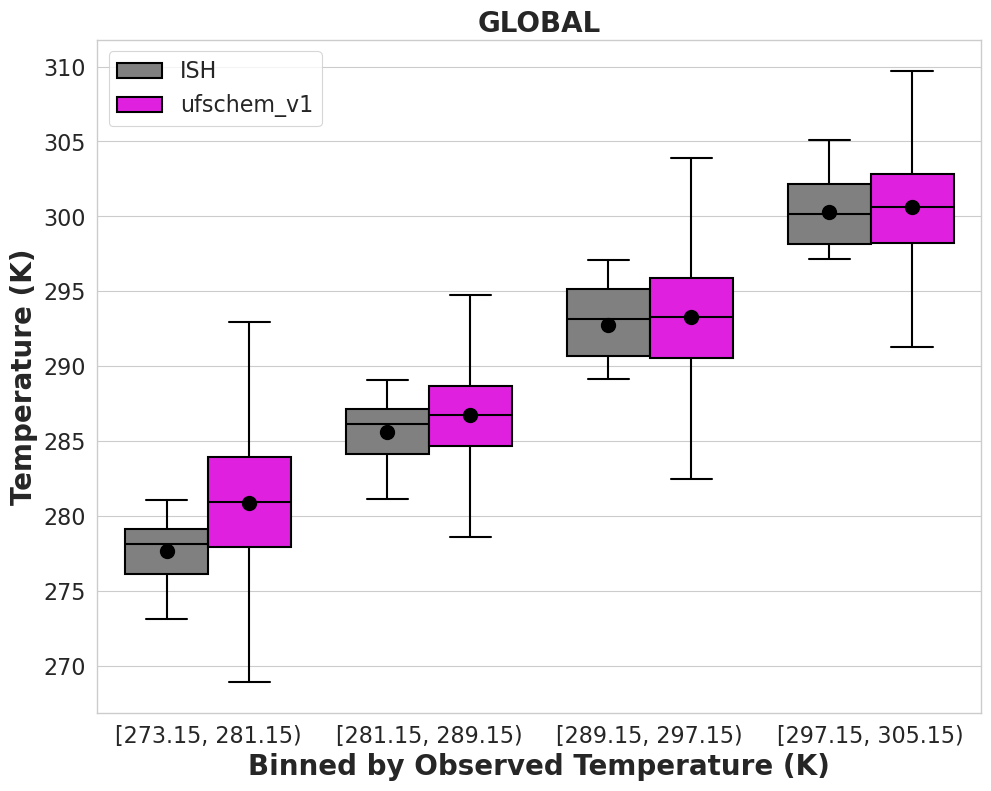

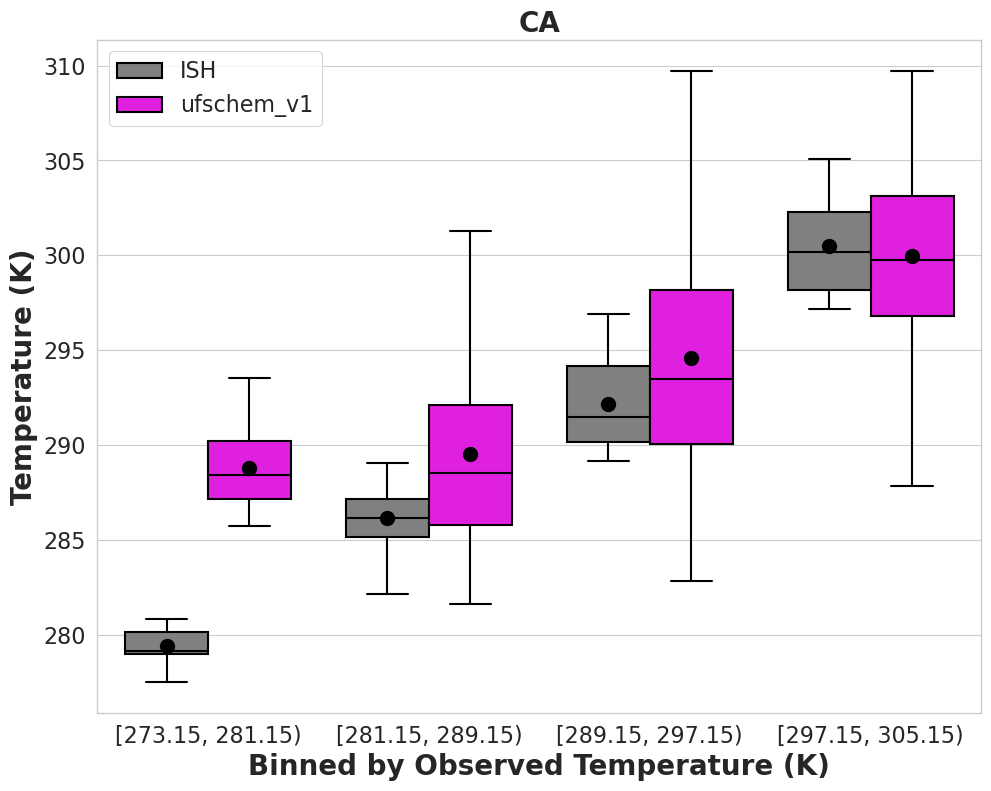

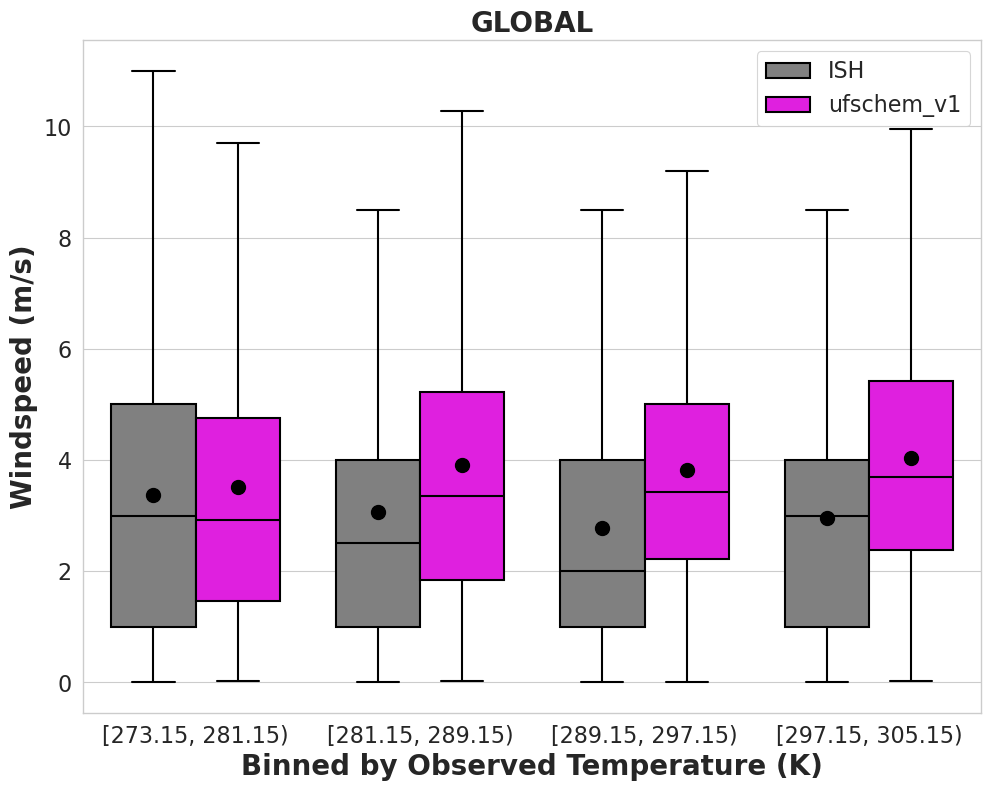

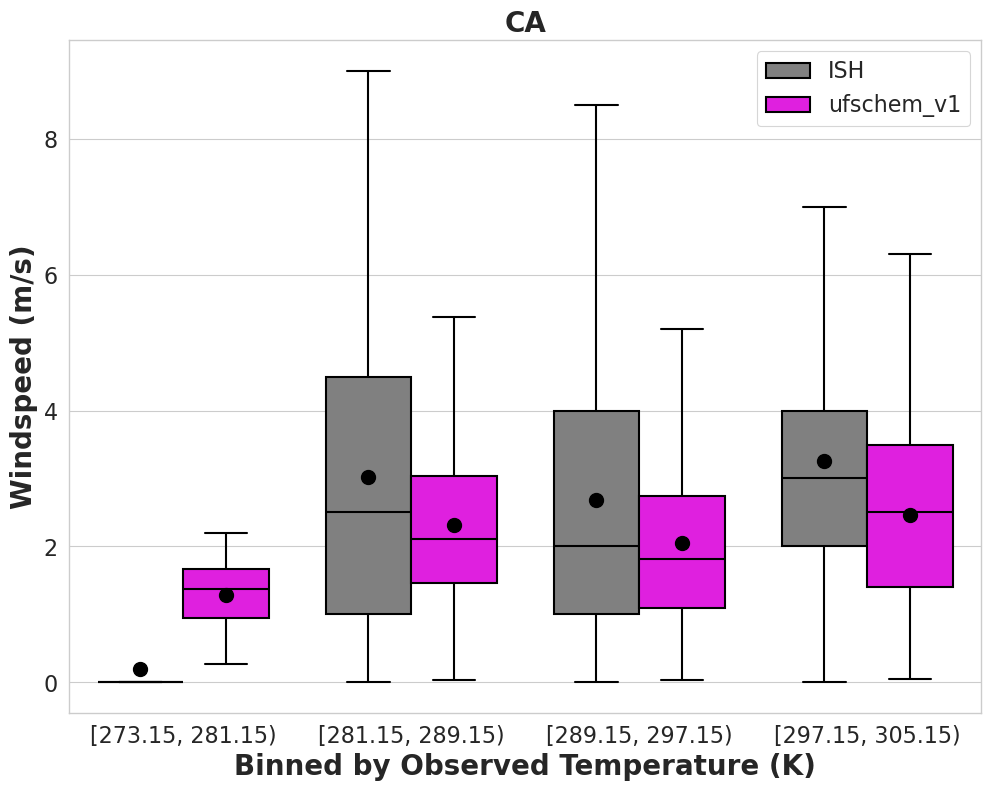

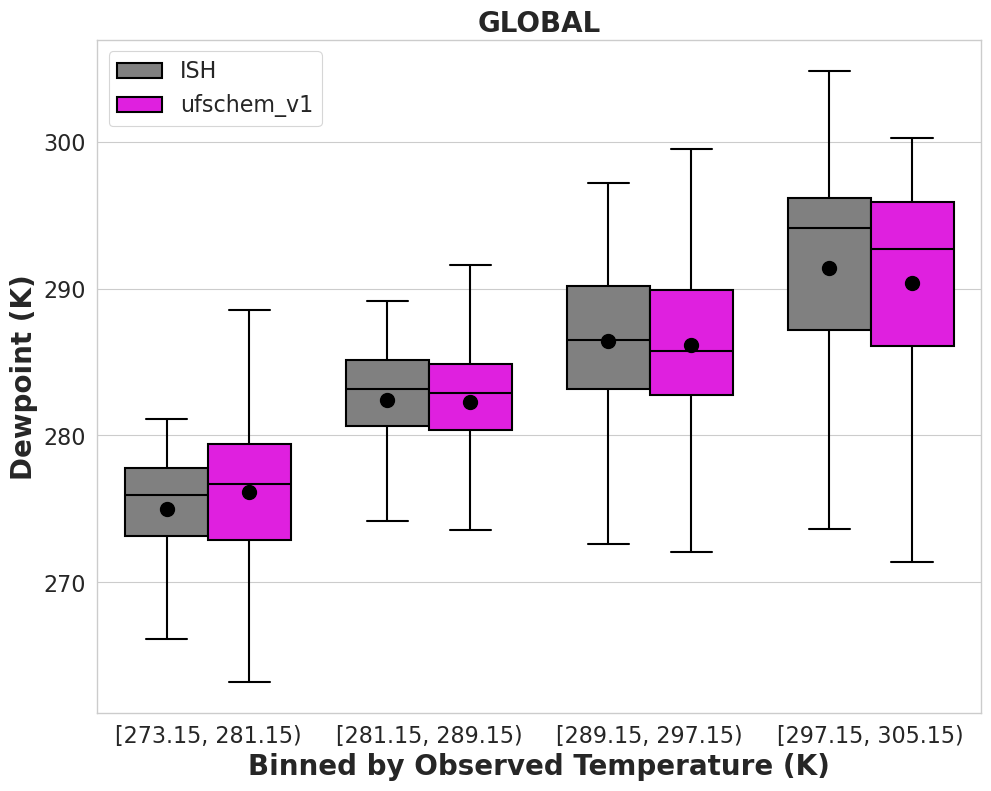

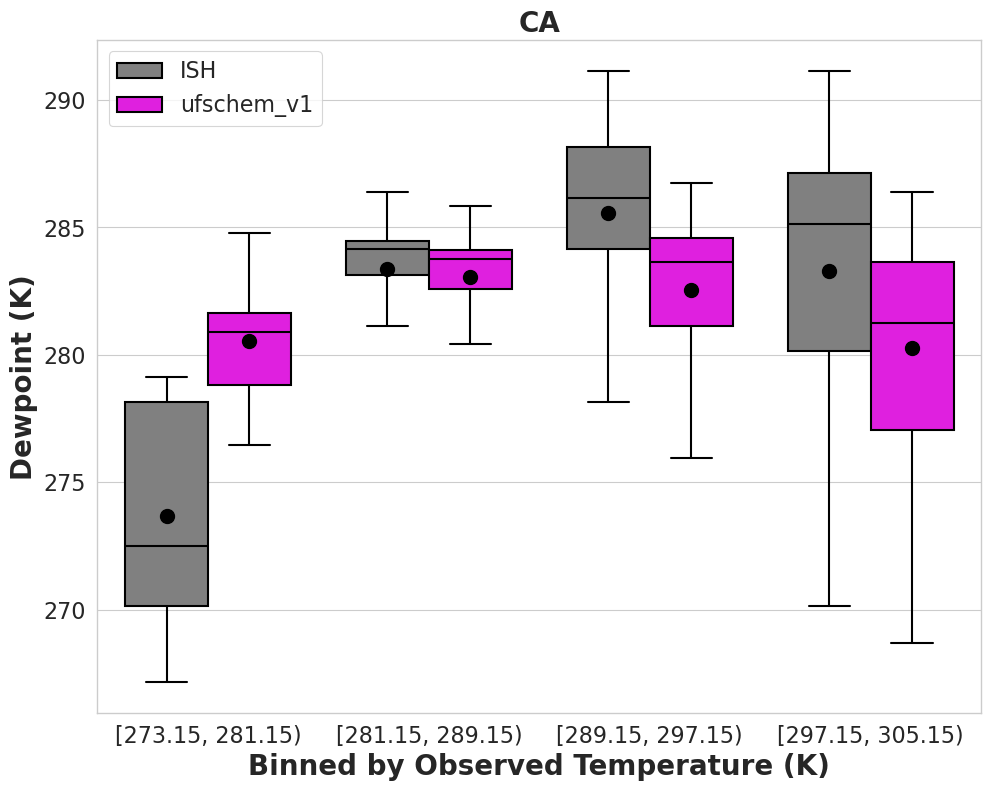

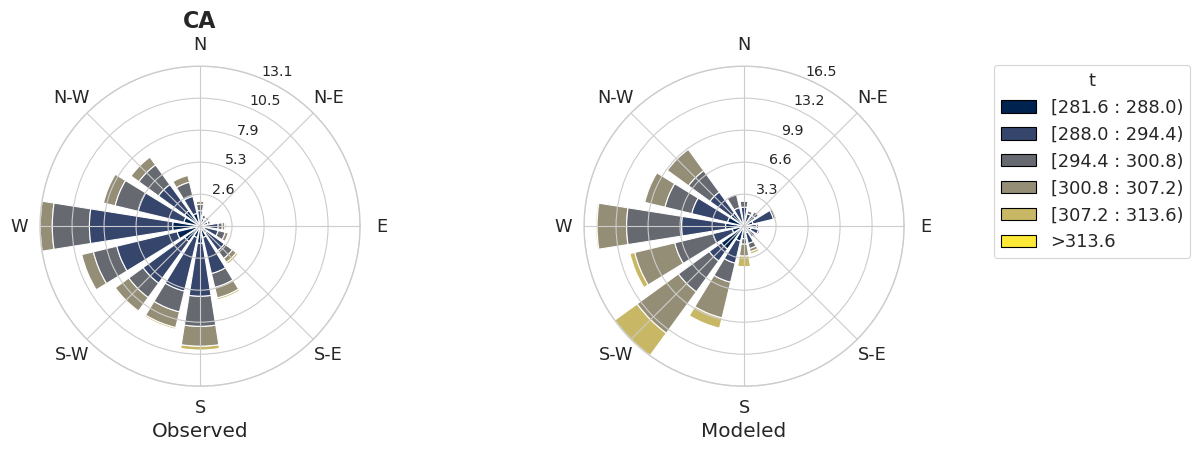

Saving rose plot to ./output/ish_ufschem/plot_grp6.rose_plot.ws.2017-07-01_00.2017-07-03_00.state.CA...


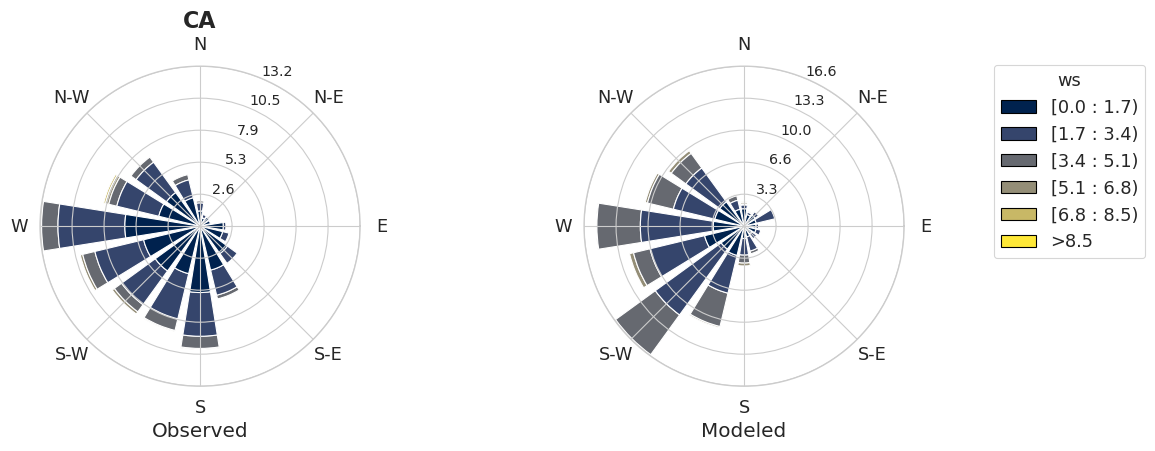

Saving rose plot to ./output/ish_ufschem/plot_grp6.rose_plot.dpt.2017-07-01_00.2017-07-03_00.state.CA...


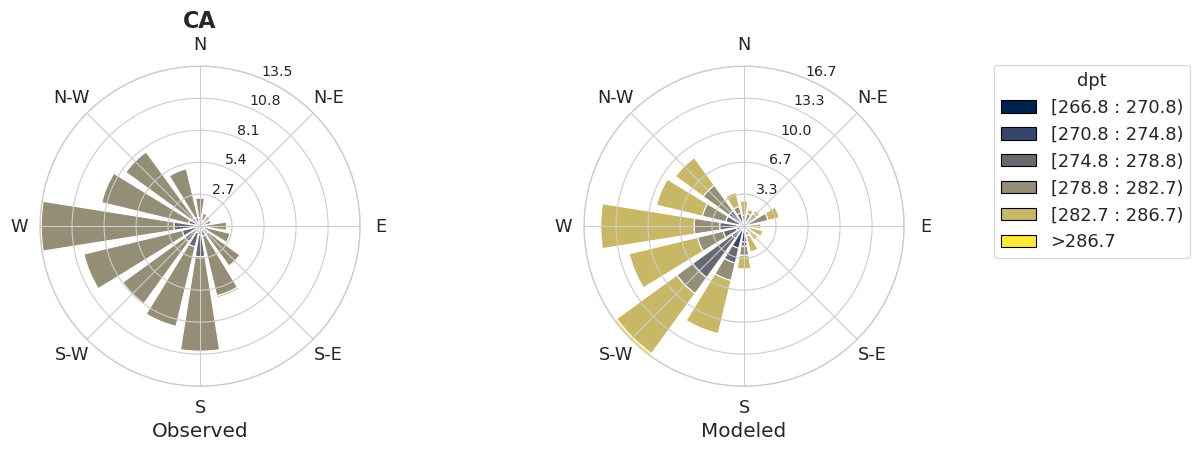

CPU times: user 2min 9s, sys: 4.66 s, total: 2min 13s
Wall time: 2min 14s


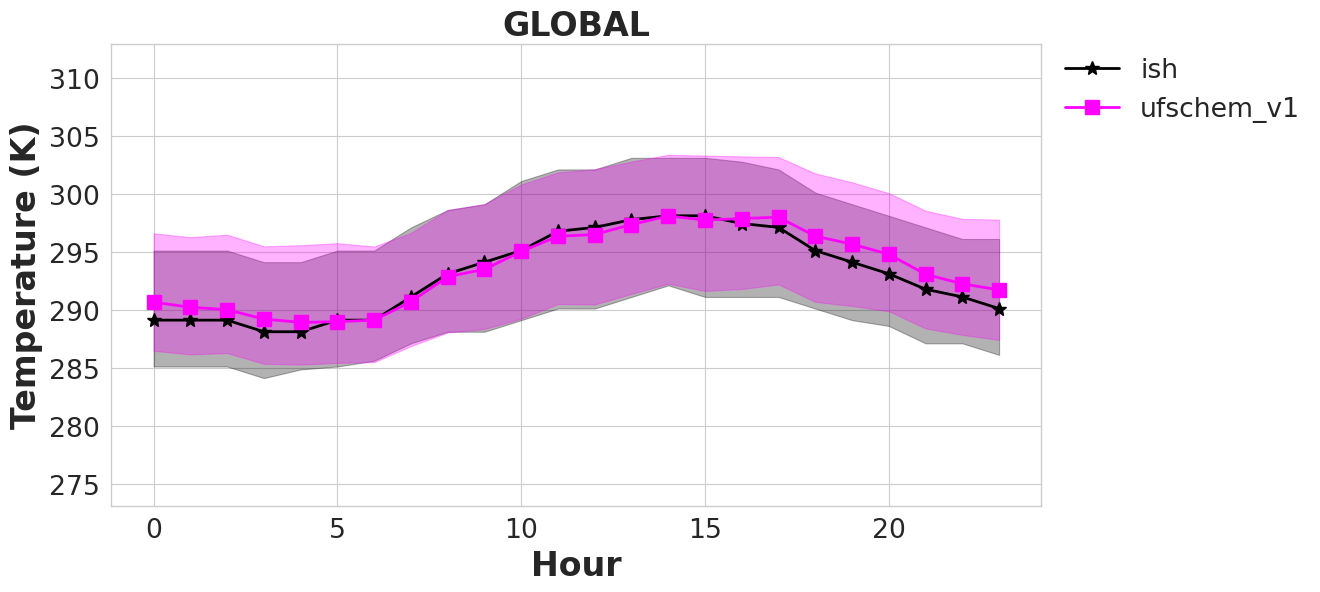

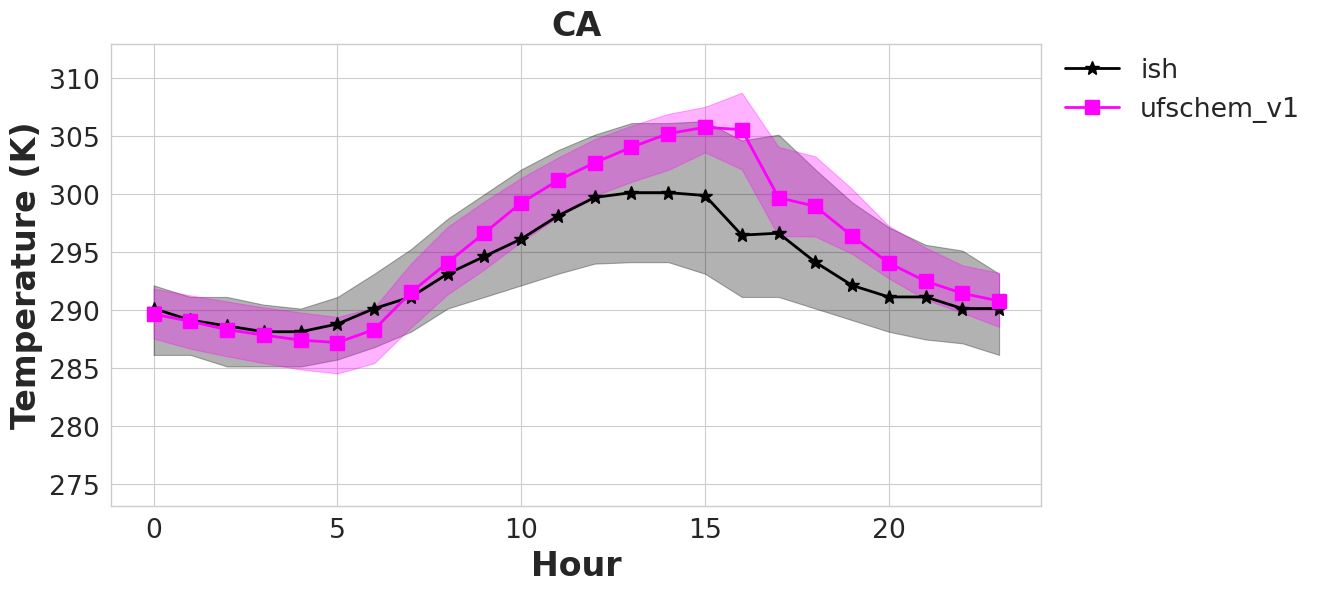

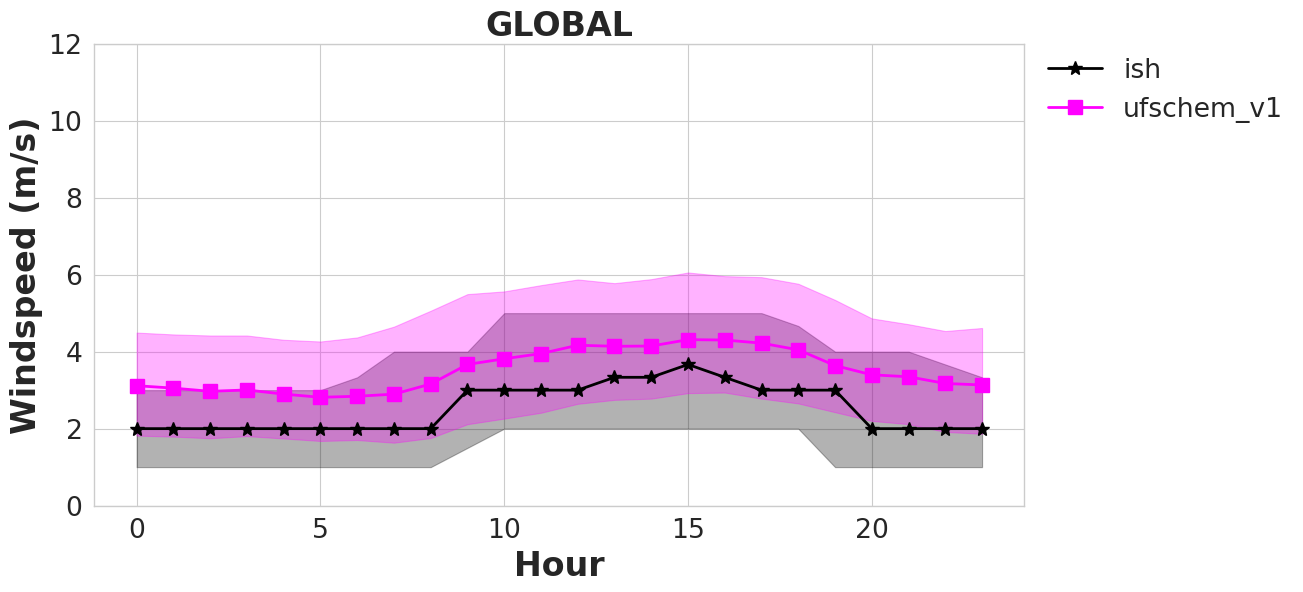

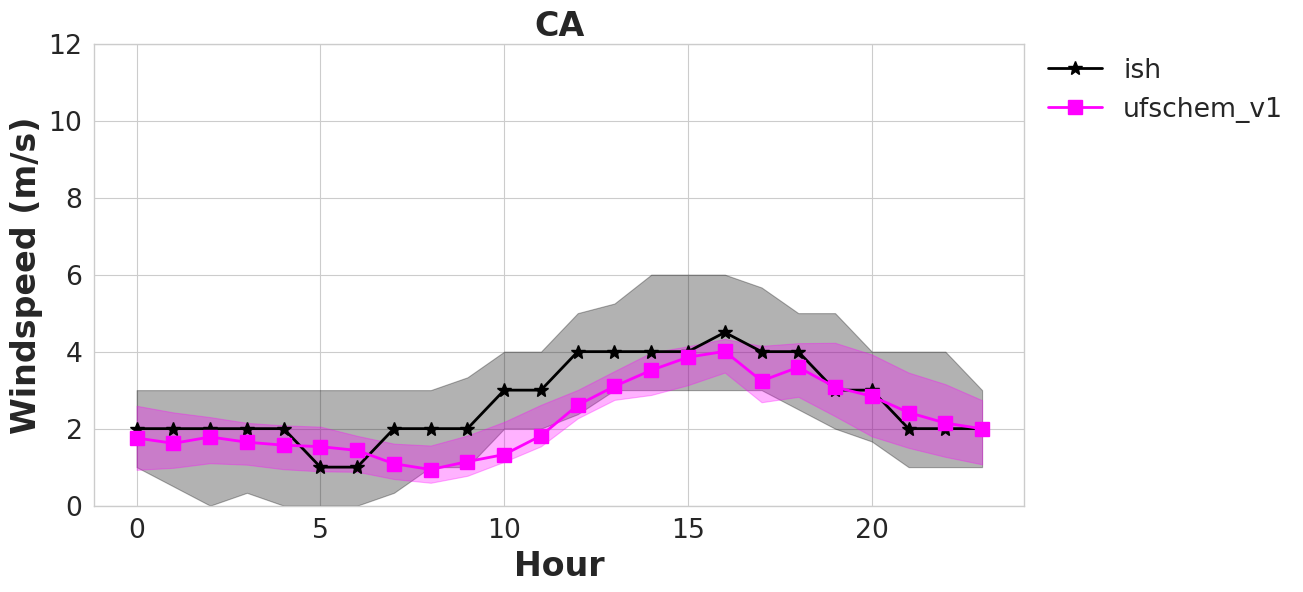

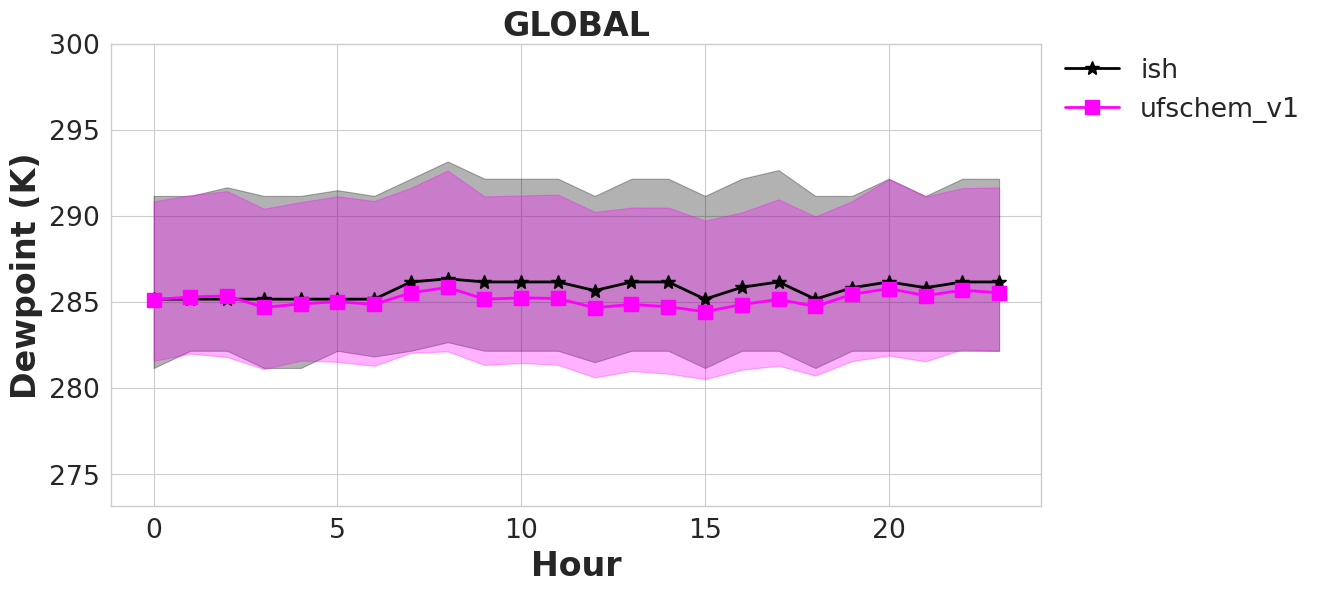

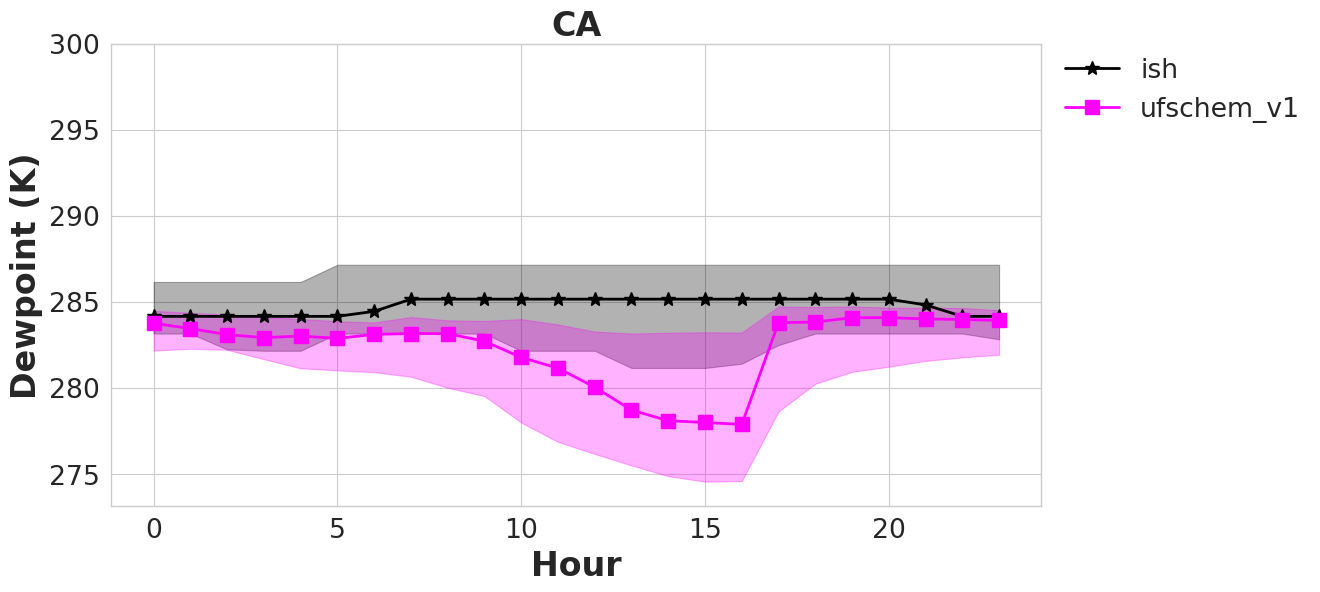

In [15]:
%%time

an.plotting()

CPU times: user 9.75 s, sys: 944 ms, total: 10.7 s
Wall time: 10.7 s


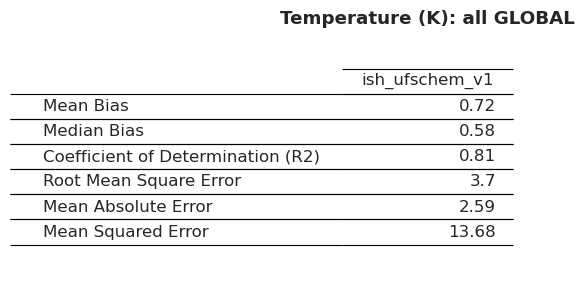

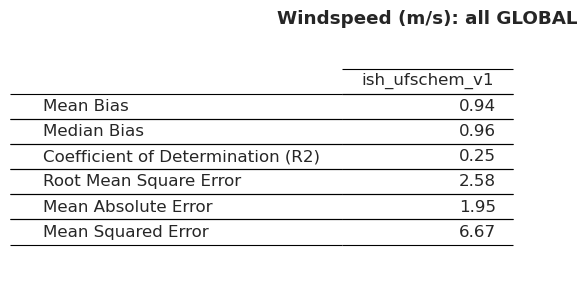

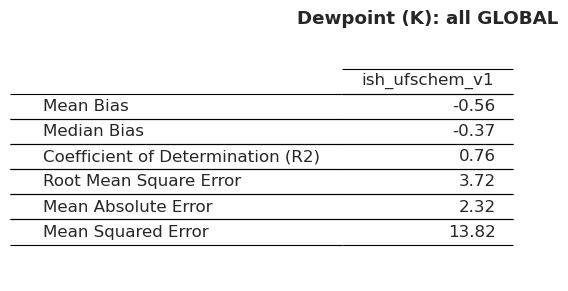

In [16]:
%%time

an.stats()

The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```